# Feature Space Analysis: SST vs Chlorophyll-a

This notebook explores the relationship between Sea Surface Temperature (SST) and Chlorophyll-a concentration, colored by month to reveal seasonal patterns.

In [11]:
# Import required libraries
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from matplotlib.colors import Normalize

## Load the Pickle Dataset

In [12]:
# Load the pickle file
with open(r'E:\satdata\Custom\yucutan_combined_sst_chlor_cdom_2005-2011.pkl', 'rb') as f:
    data = pickle.load(f)

df = data['data']
metadata = data['metadata']

print(f"Dataset loaded successfully!")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded successfully!
Date range: 2010-01-01 00:00:00 to 2020-01-01 00:00:00
Total records: 3662
Columns: ['sst', 'sst_n_points', 'chlorophyll', 'chlor_n_points', 'cdom', 'cdom_n_points']


## Annual Mean Maps (Yucatan)
These maps show the multi-year mean SST, Chlorophyll-a, and CDOM over the Yucatan region.

Computing temporal means for each product...


C:\Users\Makai\AppData\Local\Temp\ipykernel_8692\1041365484.py:14: RuntimeWarning: Mean of empty slice
  return np.nanmean(stacked, axis=0)


Mean grids created:
  SST: (250, 250)
  Chlorophyll: (250, 250)
  CDOM: (250, 250)
Region: [-92.0, 17.5] to [-86.5, 22.5]


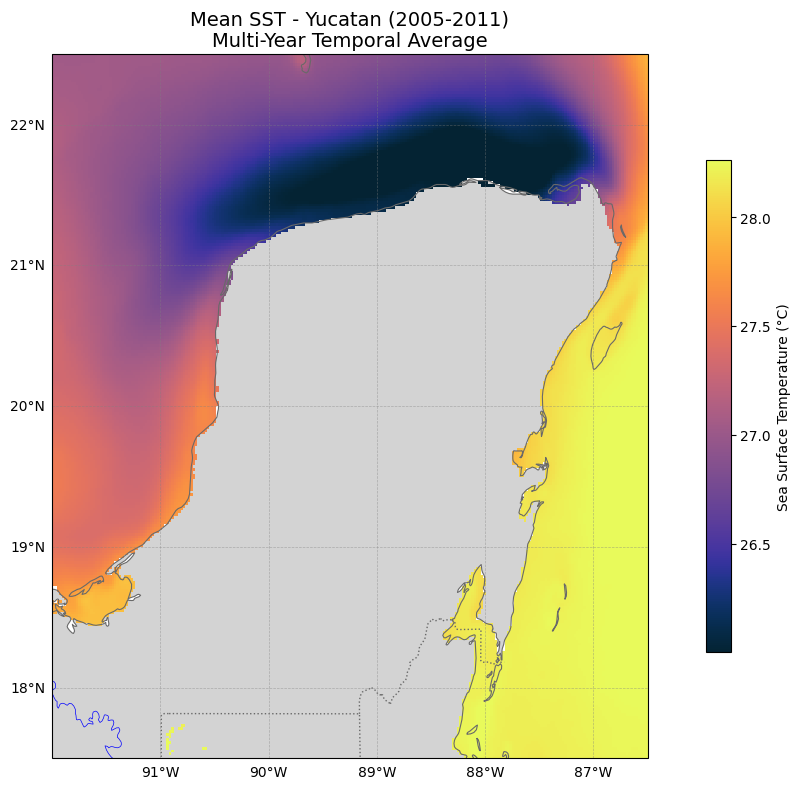

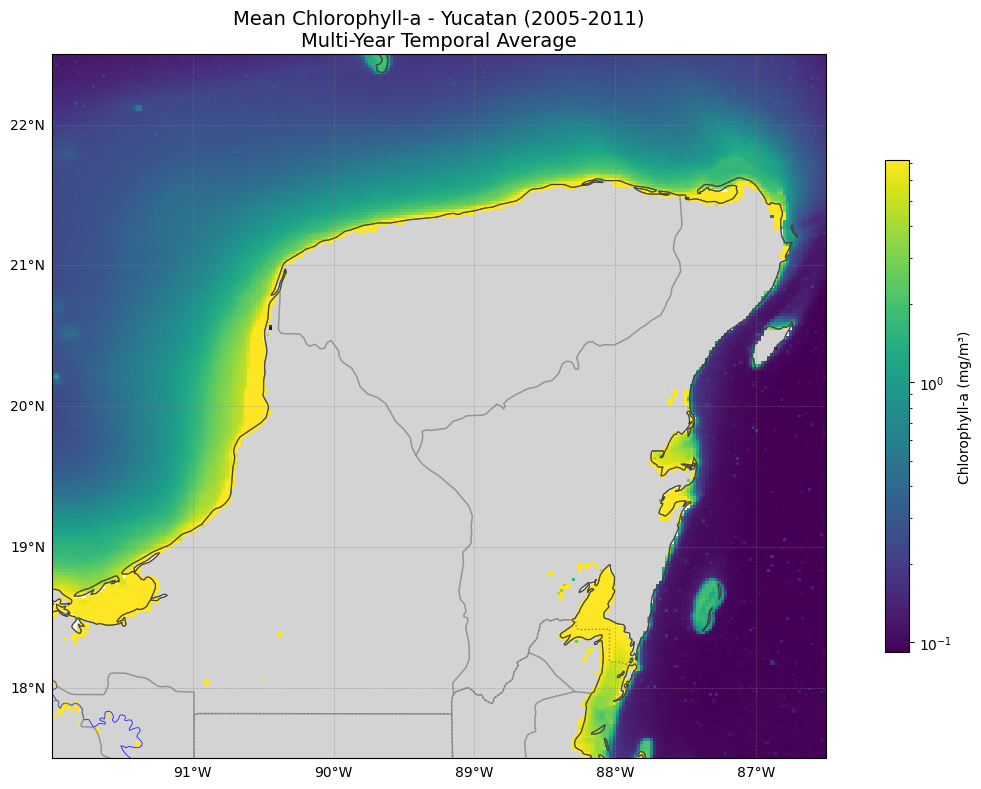

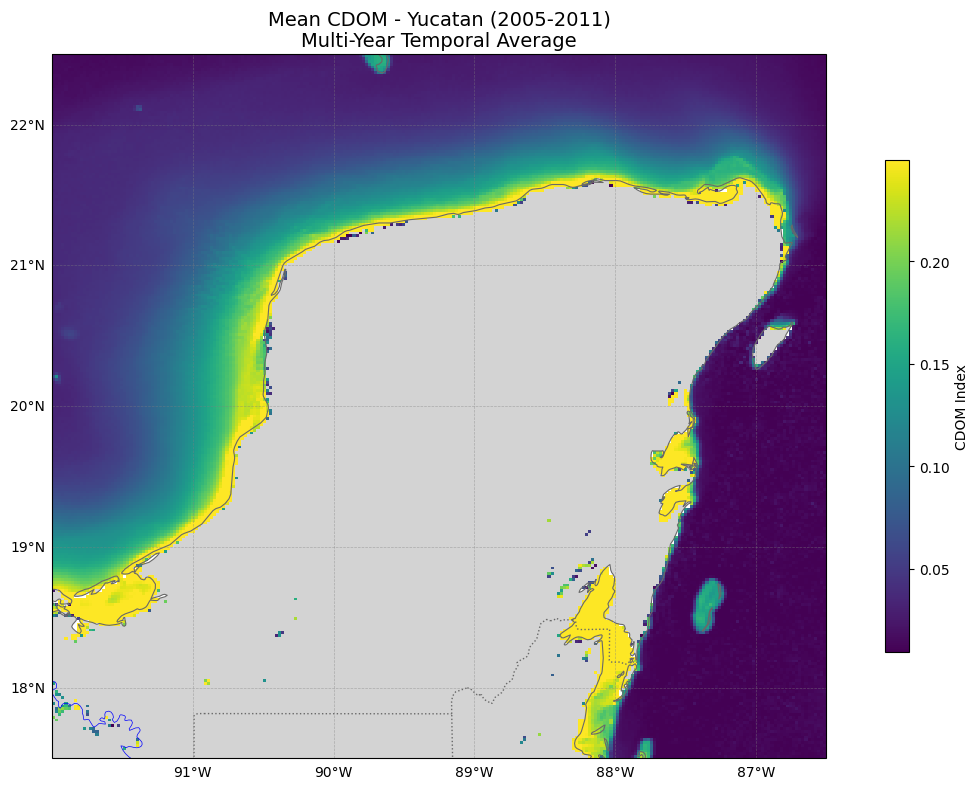

In [13]:
# Compute temporal means for each product
def extract_temporal_mean(df, column_name):
    arrays = []
    for _, row in df.iterrows():
        data = row.get(column_name)
        if data is None:
            continue
        if isinstance(data, float) and np.isnan(data):
            continue
        arrays.append(np.array(data))
    if not arrays:
        return None
    stacked = np.stack(arrays, axis=0)
    return np.nanmean(stacked, axis=0)

lat_edges = metadata.get('lat_edges')
lon_edges = metadata.get('lon_edges')
bbox = metadata.get('bbox')
grid_shape = metadata.get('grid_shape')

if lat_edges is None or lon_edges is None or bbox is None:
    raise ValueError('Missing grid metadata (lat_edges, lon_edges, bbox).')

lon_min, lon_max, lat_min, lat_max = bbox
lat_bins, lon_bins = grid_shape

print('Computing temporal means for each product...')
sst_mean = extract_temporal_mean(df, 'sst')
chlor_mean = extract_temporal_mean(df, 'chlorophyll')
cdom_mean = extract_temporal_mean(df, 'cdom')

print('Mean grids created:')
print(f"  SST: {None if sst_mean is None else sst_mean.shape}")
print(f"  Chlorophyll: {None if chlor_mean is None else chlor_mean.shape}")
print(f"  CDOM: {None if cdom_mean is None else cdom_mean.shape}")
print(f"Region: [{lon_min}, {lat_min}] to [{lon_max}, {lat_max}]")

# Plot SST mean
if sst_mean is not None:
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_aspect(1.3, adjustable='box', anchor='C')
    valid_sst = sst_mean[~np.isnan(sst_mean)]
    if len(valid_sst) > 0:
        sst_vmin = np.percentile(valid_sst, 5)
        sst_vmax = np.percentile(valid_sst, 95)
    else:
        sst_vmin, sst_vmax = 20, 32
    sst_mesh = ax.pcolormesh(
        lon_edges, lat_edges, sst_mean,
        cmap=cmocean.cm.thermal, shading='auto',
        vmin=sst_vmin, vmax=sst_vmax,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimGray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='dimGray')
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=True,
        linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    plt.colorbar(sst_mesh, label='Sea Surface Temperature (°C)', shrink=0.7)
    plt.title('Mean SST - Yucatan (2005-2011)\nMulti-Year Temporal Average', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot Chlorophyll-a mean
if chlor_mean is not None:
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    valid_chlor = chlor_mean[~np.isnan(chlor_mean)]
    if len(valid_chlor) > 0:
        vmin = np.percentile(valid_chlor, 5)
        vmax = np.percentile(valid_chlor, 95)
        if vmin <= 0:
            vmin = 0.01
        if vmax <= vmin:
            vmax = vmin * 10
    else:
        vmin, vmax = 0.01, 10
    chlor_mesh = ax.pcolormesh(
        lon_edges, lat_edges, chlor_mean,
        cmap='viridis', shading='auto',
        norm=colors.LogNorm(vmin=vmin, vmax=vmax),
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='gray', alpha=0.5)
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=True,
        linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    plt.colorbar(chlor_mesh, label='Chlorophyll-a (mg/m³)', shrink=0.7)
    plt.title('Mean Chlorophyll-a - Yucatan (2005-2011)\nMulti-Year Temporal Average', fontsize=14)
    plt.tight_layout()
    plt.show()

# Plot CDOM mean
if cdom_mean is not None:
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    valid_cdom = cdom_mean[~np.isnan(cdom_mean)]
    if len(valid_cdom) > 0:
        vmin = np.percentile(valid_cdom, 5)
        vmax = np.percentile(valid_cdom, 95)
        if vmin >= vmax:
            vmin = np.nanmin(valid_cdom)
            vmax = np.nanmax(valid_cdom)
        if vmin == vmax:
            vmin -= 0.01
            vmax += 0.01
    else:
        vmin, vmax = 0, 0.1
    cdom_mesh = ax.pcolormesh(
        lon_edges, lat_edges, cdom_mean,
        cmap='viridis', shading='auto',
        vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree()
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='dimGray')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='dimGray')
    ax.add_feature(cfeature.RIVERS, linewidth=0.5, edgecolor='blue')
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=True,
        linewidth=0.5, color='gray', alpha=0.5, linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    plt.colorbar(cdom_mesh, label='CDOM Index', shrink=0.7)
    plt.title('Mean CDOM - Yucatan (2005-2011)\nMulti-Year Temporal Average', fontsize=14)
    plt.tight_layout()
    plt.show()

## Extract and Flatten Data for Scatter Plot

In [14]:
# Extract all data points from the gridded dataset
sst_values = []
chlor_values = []
month_values = []

for date_idx, row in df.iterrows():
    # Filter for year 2015 only
    if date_idx.year != 2015:
        continue
    
    # Extract month from the date index (1-12)
    month = date_idx.month
    
    # Get SST and chlorophyll grids
    sst_grid = row['sst']
    chlor_grid = row['chlorophyll']
    
    # Skip if either grid is None or NaN
    if sst_grid is None or chlor_grid is None:
        continue
    if isinstance(sst_grid, float) and np.isnan(sst_grid):
        continue
    if isinstance(chlor_grid, float) and np.isnan(chlor_grid):
        continue
    
    # Convert to numpy arrays
    sst_array = np.array(sst_grid)
    chlor_array = np.array(chlor_grid)
    
    # Flatten the grids
    sst_flat = sst_array.flatten()
    chlor_flat = chlor_array.flatten()
    
    # Create mask for valid data (both SST and Chlor must be valid)
    valid_mask = ~np.isnan(sst_flat) & ~np.isnan(chlor_flat)
    
    # Append valid data points
    sst_values.extend(sst_flat[valid_mask])
    chlor_values.extend(chlor_flat[valid_mask])
    month_values.extend([month] * np.sum(valid_mask))

# Convert to numpy arrays
sst_values = np.array(sst_values)
chlor_values = np.array(chlor_values)
month_values = np.array(month_values)

print(f"Total valid data points before subsampling: {len(sst_values):,}")

# Subsample to 50K points if we have more than that
max_points = 15000
if len(sst_values) > max_points:
    # Generate random indices
    np.random.seed(42)  # For reproducibility
    random_indices = np.random.choice(len(sst_values), size=max_points, replace=False)
    
    # Subsample all arrays
    sst_values = sst_values[random_indices]
    chlor_values = chlor_values[random_indices]
    month_values = month_values[random_indices]
    
    print(f"Subsampled to {max_points:,} points")
else:
    print(f"Using all {len(sst_values):,} points (less than {max_points:,})")

print(f"SST range: {np.min(sst_values):.2f} to {np.max(sst_values):.2f} °C")
print(f"Chlorophyll range: {np.min(chlor_values):.4f} to {np.max(chlor_values):.4f} mg/m³")
print(f"Months represented: {sorted(np.unique(month_values))}")

Total valid data points before subsampling: 4,021,833
Subsampled to 15,000 points
SST range: 21.80 to 31.06 °C
Chlorophyll range: 0.0244 to 69.6981 mg/m³
Months represented: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


## Create Scatter Plot: SST vs Chlorophyll-a (Colored by Month)

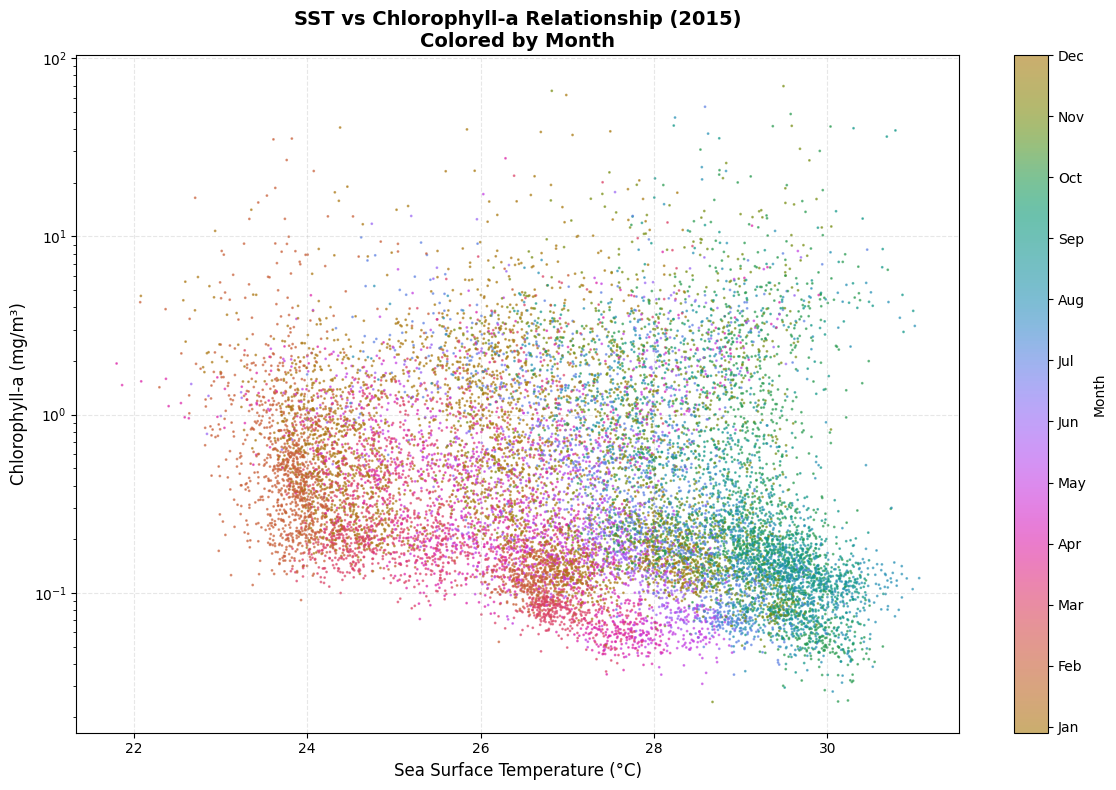

Scatter plot created with 15,000 data points


In [15]:
# Create the scatter plot
fig, ax = plt.subplots(figsize=(12, 8))

# Create scatter plot with month as color
# Use cmocean.cm.phase for cyclic month coloring (reversed)
scatter = ax.scatter(
    sst_values, 
    chlor_values,
    c=month_values,
    cmap=cmocean.cm.phase,
    s=1,  # Small point size for large dataset
    alpha=0.6,  # Transparency to show density
    vmin=12,  # Flipped: December at bottom
    vmax=1,   # January at top
    rasterized=True  # Rasterize for better performance with many points
)

# Set y-axis to log scale (typical for chlorophyll)
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Sea Surface Temperature (°C)', fontsize=12)
ax.set_ylabel('Chlorophyll-a (mg/m³)', fontsize=12)
ax.set_title('SST vs Chlorophyll-a Relationship (2015)\nColored by Month', 
             fontsize=14, fontweight='bold')

# Add colorbar with month labels (reversed order)
cbar = plt.colorbar(scatter, ax=ax, label='Month', ticks=np.arange(1, 13))
cbar.ax.set_yticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Add grid
ax.grid(True, alpha=0.3, linestyle='--')

# Tight layout
plt.tight_layout()
plt.show()

print(f"Scatter plot created with {len(sst_values):,} data points")